# Twin4Build: Full Workflow Example

This notebook demonstrates the complete Twin4Build workflow on a single model:

1. **Semantic Model → Simulation Model** (Translator): Load a semantic description from an Excel file and automatically generate a simulation model
2. **Simulation Model → Calibrated Model** (Estimator): Calibrate the simulation model parameters against real sensor data
3. **Calibrated Model → Optimized Control** (Optimizer): Optimize the valve position schedule to minimize energy use while maintaining thermal comfort

The example uses a single-room office model with:
- A building space with thermal and mass balance
- A space heater with valve control
- Temperature and CO2 controllers with dampers
- Sensors for temperature, CO2, valve position, and damper position

## 1. Setup

Import the necessary packages. If running in Google Colab, uncomment the pip install line.
Note that Colab has a dependency issue and asks you to restart the runtime. It will work after you restart the runtime and run the cell a 2nd time.

In [4]:
# %pip install twin4build # Uncomment in google colab
import twin4build as tb
import datetime
from dateutil import tz
import twin4build.examples.utils as utils

---
# Part 1: Semantic Model → Simulation Model (Translator)

The Translator automatically generates a simulation model from a semantic description stored in an Excel file. The semantic file contains building component definitions using SAREF ontologies, component relationships, parameter specifications, and system topology.

We also define a custom configuration function (`fcn`) that adds connections and data sources not captured in the semantic model—such as supply water temperature, boundary conditions, sensor data files, and control setpoints.

### 1.1 Define Post-Translation Configuration

This function is called after the translator generates the simulation model. It adds:
- Supply water temperature and boundary temperature schedules
- Sensor data file connections (temperature, CO2, valve position, damper position, supply air temperature)
- Control setpoints (CO2, occupancy, temperature heating setpoint)
- Outdoor environment data (temperature, irradiation, CO2 concentration)

In [5]:
def fcn(self):
    supply_water_schedule = tb.ScheduleSystem(
        weekDayRulesetDict={
            "ruleset_default_value": 60,
            "ruleset_start_minute": [],
            "ruleset_end_minute": [],
            "ruleset_start_hour": [],
            "ruleset_end_hour": [],
            "ruleset_value": []
        },
        id="supply_water_schedule"
    )

    boundary_temp_schedule = tb.ScheduleSystem(
        weekDayRulesetDict={
            "ruleset_default_value": 21,
            "ruleset_start_minute": [],
            "ruleset_end_minute": [],
            "ruleset_start_hour": [],
            "ruleset_end_hour": [],
            "ruleset_value": [],
        },
        weekendRulesetDict={
            "ruleset_default_value": 21,
            "ruleset_start_minute": [],
            "ruleset_end_minute": [],
            "ruleset_start_hour": [],
            "ruleset_end_hour": [],
            "ruleset_value": [],
        },
        id="boundary_temp_schedule"
    )

    self.add_connection(boundary_temp_schedule, self.components["office"], "scheduleValue", "boundaryTemperature")
    self.add_connection(supply_water_schedule, self.components["office_space_heater"], "scheduleValue", "supplyWaterTemperature")

    DATA_ROOT = r"C:\Users\jabj\Documents\python\Twin4build-Case-Studies\DP37\model\data"

    # self.components["office_temperature_sensor"].useSpreadsheet = True
    # self.components["office_temperature_sensor"].filename = utils.get_path(["estimator_example", "temperature_sensor.csv"])
    self.components["office_temperature_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_020B\OD095_01_020B_L95_LC02_BTA012_S1.plc_SENSOR_VALUE.csv"
    self.components["office_temperature_sensor"].datecolumn = 2
    self.components["office_temperature_sensor"].valuecolumn = 4

    # self.components["office_co2_sensor"].useSpreadsheet = True
    # self.components["office_co2_sensor"].filename = utils.get_path(["estimator_example", "co2_sensor.csv"])
    self.components["office_co2_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_020B\OD095_01_020B_L95_LC02_BQA010_S2.plc_SENSOR_VALUE.csv"
    self.components["office_co2_sensor"].datecolumn = 2
    self.components["office_co2_sensor"].valuecolumn = 4

    # self.components["office_valve_position_sensor"].useSpreadsheet = True
    # self.components["office_valve_position_sensor"].filename = utils.get_path(["estimator_example", "valve_position_sensor.csv"])
    self.components["office_valve_position_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_020B\OD095_01_020B_L95_LC02_QNA020_C1.plc_ACTUATOR_VALUE.csv"
    self.components["office_valve_position_sensor"].datecolumn = 2
    self.components["office_valve_position_sensor"].valuecolumn = 4

    # self.components["office_damper_position_sensor"].useSpreadsheet = True
    # self.components["office_damper_position_sensor"].filename = utils.get_path(["estimator_example", "damper_position_sensor.csv"])
    self.components["office_damper_position_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_020B\OD095_01_020B_L95_LC02_QNB021_C1.plc_ACTUATOR_VALUE.csv"
    self.components["office_damper_position_sensor"].datecolumn = 2
    self.components["office_damper_position_sensor"].valuecolumn = 4

    # self.components["BTA004"].useSpreadsheet = True
    # self.components["BTA004"].filename = utils.get_path(["estimator_example", "supply_air_temperature.csv"])
    self.components["BTA004"].filename = DATA_ROOT + r"\Time series\HF04\OD095_01_032A_J95_HF04_BTA004_S1.plc_SENSOR_VALUE.csv"
    self.components["BTA004"].datecolumn = 2
    self.components["BTA004"].valuecolumn = 4

    self.components["office_co2_setpoint"].weekDayRulesetDict = {
        "ruleset_default_value": 900,
        "ruleset_start_minute": [],
        "ruleset_end_minute": [],
        "ruleset_end_hour": [],
        "ruleset_start_hour": [],
        "ruleset_value": []
    }

    self.components["office_occupancy_profile"].weekDayRulesetDict = {
        "ruleset_default_value": 0,
        "ruleset_start_minute": [],
        "ruleset_end_minute": [],
        "ruleset_start_hour": [],
        "ruleset_end_hour": [],
        "ruleset_value": []
    }

    # self.components["office_temperature_heating_setpoint"].useSpreadsheet = True
    # self.components["office_temperature_heating_setpoint"].filename = utils.get_path(["estimator_example", "temperature_heating_setpoint.csv"])
    self.components["office_temperature_heating_setpoint"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_020B\OD095_01_020B_L95_LC02_KFD004.plc_PID_SP.csv"
    self.components["office_temperature_heating_setpoint"].datecolumn = 2
    self.components["office_temperature_heating_setpoint"].valuecolumn = 4
    

    self.components["outdoor_environment"].useSpreadsheet = True
    self.components["outdoor_environment"].filename_outdoorTemperature = utils.get_path(["estimator_example", "outdoor_environment.csv"])
    self.components["outdoor_environment"].datecolumn_outdoorTemperature = 0
    self.components["outdoor_environment"].valuecolumn_outdoorTemperature = 1

    self.components["outdoor_environment"].filename_globalIrradiation = utils.get_path(["estimator_example", "outdoor_environment.csv"])
    self.components["outdoor_environment"].datecolumn_globalIrradiation = 0
    self.components["outdoor_environment"].valuecolumn_globalIrradiation = 2

    self.components["outdoor_environment"].filename_outdoorCo2Concentration = utils.get_path(["estimator_example", "outdoor_environment.csv"])
    self.components["outdoor_environment"].datecolumn_outdoorCo2Concentration = 0
    self.components["outdoor_environment"].valuecolumn_outdoorCo2Concentration = 3

### 1.2 Load and Translate the Semantic Model

Create a model, load the semantic description from the Excel file, and apply the post-translation configuration. The `model.load()` call internally runs the Translator to produce an executable simulation model.

In [6]:
# model = tb.Model(id="full_workflow_example")

# filename = utils.get_path(["estimator_example", "one_room_example_model.xlsm"])
# model.load(semantic_model_filename=filename, fcn=fcn, verbose=0)

# # Serialize the model for later use
# print("Serializing model...")
# model.serialize()
# print(model)


model = tb.Model(id="full_workflow_example")
# Get the directory for where it was saved
filename_simulation, _ = model._simulation_model._semantic_model.get_dir(filename="instance_graph.ttl")
model.load(simulation_model_filename=filename_simulation)

print(model)

+-------------------------------------------------------------------------------------------------------------------------------+
|                                          Model overview    id: full_workflow_example                                          |
+---------------------------------------------+---------------------------------------------------------------------------------+
|  Number of components in simulation model:  |                                        18                                       |
+---------------------------------------------+---------------------------------------------------------------------------------+
| Number of connections in simulation model:  |                                        46                                       |
+---------------------------------------------+---------------------------------------------------------------------------------+
|              Model directory:               | C:\Users\jabj\AppData\Local\Temp\1\generat

### 1.3 Visualize the Models

Visualize both the semantic model graph and the simulation model graph to understand the component topology.

In [7]:
# instance_style = {
#     "http://example.org/building#cooling_coil_airside": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#cooling_coil_waterside": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#cooling_coil": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#cooling_system": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#heating_system": {"fill_color": ["#873939", "#873939", None, None]},
#     "http://example.org/building#ventilation_system": {"fill_color": ["#44546A", "#44546A", None, None]},
# }

# query = """
#     CONSTRUCT { ?s ?p ?o }
#     WHERE {
#         ?s ?p ?o .
#         FILTER (?p != rdf:type && ?p != rdfs:subClassOf)
#         FILTER NOT EXISTS { ?s rdf:type s4syst:System }
#         FILTER NOT EXISTS { ?o rdf:type s4syst:System }
#     }
# """
# initial_node = "http://example.org/building#office"
# model.semantic_model.visualize(
#     format="svg", instance_style=instance_style, deduplicate_inverse=True,
#     include_full_uri=False, query=query, initial_node=initial_node,
#     node_limit=35, traversal_mode="bfs", dpi=800
# )
# model.simulation_model.visualize(
#     format="svg", instance_style=instance_style, deduplicate_inverse=True,
#     include_full_uri=False, literals=False, dpi=800, compressed=True
# )

---
# Part 2: Simulation Model → Calibrated Model (Estimator)

With the simulation model ready, we now calibrate its parameters against real sensor data. The Estimator uses automatic differentiation (AD) with the SLSQP optimizer to find parameter values that minimize the discrepancy between simulated and measured outputs.

### 2.1 Set Up Simulation Parameters

Define the time periods and step size for estimation. We use two periods: one for training and one for validation.

In [8]:
simulator = tb.Simulator(model)
step_size = 1200  # 20 minutes in seconds

start_time = [
    datetime.datetime(year=2023, month=11, day=27, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
    # datetime.datetime(year=2023, month=12, day=2, hour=0, minute=0, second=0,
    #                   tzinfo=tz.gettz("Europe/Copenhagen")),
]
end_time = [
    datetime.datetime(year=2023, month=12, day=4, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
    # datetime.datetime(year=2023, month=12, day=5, hour=0, minute=0, second=0,
    #                   tzinfo=tz.gettz("Europe/Copenhagen")),
]

print(start_time[0].weekday())
print(end_time[0].weekday())

# print(f"Estimation periods: {len(start_time)}")
# print(f"  Period 1: {start_time[0]} to {end_time[0]}")
# print(f"  Period 2: {start_time[1]} to {end_time[1]}")
# print(f"Step size: {step_size} seconds ({step_size/60} minutes)")

0
0


### 2.2 Identify Model Components

Get references to the key components whose parameters we want to estimate.

In [9]:
space = model.components["office"]
space_heater = model.components["office_space_heater"]
heating_controller = model.components["office_temperature_heating_controller"]
co2_controller = model.components["office_co2_controller"]
space_heater_valve = model.components["office_space_heater_valve"]
supply_damper = model.components["office_supply_damper"]
exhaust_damper = model.components["office_exhaust_damper"]

print("Key components:")
for name, comp in [("Building space", space), ("Space heater", space_heater),
                    ("Heating controller", heating_controller), ("CO2 controller", co2_controller),
                    ("Valve", space_heater_valve), ("Supply damper", supply_damper),
                    ("Exhaust damper", exhaust_damper)]:
    print(f"  {name}: {comp.id}")

Key components:
  Building space: office
  Space heater: office_space_heater
  Heating controller: office_temperature_heating_controller
  CO2 controller: office_co2_controller
  Valve: office_space_heater_valve
  Supply damper: office_supply_damper
  Exhaust damper: office_exhaust_damper


### 2.3 Define Target Parameters for Estimation

Specify the parameters to estimate with their initial values, lower bounds, and upper bounds. These cover:
- Thermal parameters (capacitances, resistances, radiation factors)
- Mass parameters (volume, CO2 generation, infiltration rate)
- Space heater parameters (thermal mass, conductance)
- Controller PID gains
- Valve and damper parameters

In [10]:
parameters = [
    # Thermal parameters
    (space, "thermal.C_air", 1e+5, 1e+4, 5e+5),
    (space, "thermal.C_wall", 1e+6, 1e+5, 2e+6),
    (space, "thermal.C_boundary", 1e+6, 1e+4, 1e+6),
    (space, "thermal.R_out", 0.15, 0.01, 0.5),
    (space, "thermal.R_in", 0.07, 0.01, 0.5),
    (space, "thermal.R_boundary", 0.004, 0.0001, 1),
    (space, "thermal.f_wall", 0.3, 0, 1),
    (space, "thermal.f_air", 0.1, 0, 1),
    (space, "thermal.Q_occ_gain", 100.0, 10, 200),

    # Mass parameters
    # (space, "mass.V", 100, 10, 1000),
    # (space, "mass.G_occ", 8.18e-6, 1e-8, 1e-4),
    # (space, "mass.m_inf", 0.001, 1e-6, 0.3),

    # Space heater parameters
    (space_heater, "thermalMassHeatCapacity", 2e+5, 1000, 2e+5),
    (space_heater, "UA", 30, 1, 100),

    # Controller PID parameters (private = each controller gets its own values)
    (heating_controller, "kp", 0.005, 1e-5, 1, "private"),
    (co2_controller, "kp", 0.0001, 1e-5, 1, "private"),
    ([heating_controller, co2_controller], "Ti", 30, 1, 300, "private"),
    ([heating_controller, co2_controller], "Td", 0, 0, 1, "private"),

    # Valve parameters
    (space_heater_valve, "waterFlowRateMax", 0.003, 1e-6, 0.1),
    (space_heater_valve, "valveAuthority", 0.5, 0.4, 1),

    # Damper parameters (private = each damper gets its own values)
    ([supply_damper, exhaust_damper], "a", 1, 1, 10, "private"),
    ([supply_damper, exhaust_damper], "nominalAirFlowRate", 0.001, 1e-5, 1, "private"),
]

# ffice.thermal.C_air = 367397.2694428787
# office.thermal.C_wall = 874862.9751845048
# office.thermal.C_boundary = 293416.5812982547
# office.thermal.R_out = 0.12068150511092156
# office.thermal.R_in = 0.4609648812302245
# office.thermal.R_boundary = 0.013392133370065114
# office.thermal.f_wall = 1.4585108615841165e-15
# office.thermal.f_air = 4.904362374564428e-15
# office.thermal.Q_occ_gain = 100.0
# office_space_heater.thermalMassHeatCapacity = 82291.28537563063
# office_space_heater.UA = 17.010091159556097
# office_temperature_heating_controller.kp = 0.0050313362575371305
# office_co2_controller.kp = 0.00010000000000000009
# office_temperature_heating_controller.Ti = 1.000000000000038
# office_co2_controller.Ti = 10.000000000000002
# office_temperature_heating_controller.Td = 0.00014566232001379684
# office_co2_controller.Td = 0.0
# office_space_heater_valve.waterFlowRateMax = 0.0005277347080587186
# office_space_heater_valve.valveAuthority = 0.9999999999999964
# office_supply_damper.a = 1.0
# office_exhaust_damper.a = 1.0
# office_supply_damper.nominalAirFlowRate = 0.001
# office_exhaust_damper.nominalAirFlowRate = 0.001

space_heater.initialize_UA = False

print(f"Total parameter groups: {len(parameters)}")

Total parameter groups: 19


### 2.4 Configure Measuring Devices

Define the sensors that provide measurement data for calibration, along with their standard deviations (noise levels).

In [11]:
percentile = 2
measurements = [
    (model.components["office_valve_position_sensor"], 0.05 / percentile),
    (model.components["office_temperature_sensor"], 0.01 / percentile),
    # (model.components["office_damper_position_sensor"], 0.05 / percentile),
]

print("Measuring devices for calibration:")
for device, sd in measurements:
    print(f"  {device.id} (sd={sd})")

Measuring devices for calibration:
  office_valve_position_sensor (sd=0.025)
  office_temperature_sensor (sd=0.005)


### 2.5 Run Initial Simulation (Before Calibration)

Simulate with the initial parameter guesses to establish a baseline.

In [12]:
# Set initial parameter values (x0) before simulation
x0_values = []
x0_components = []
x0_names = []
x0_min = []
x0_max = []
for entry in parameters:
    comp, name, val, lo, hi = entry[0], entry[1], entry[2], entry[3], entry[4]
    if isinstance(comp, list):
        for c in comp:
            x0_values.append(val)
            x0_components.append(c)
            x0_names.append(name)
            x0_min.append(lo)
            x0_max.append(hi)
    else:
        x0_values.append(val)
        x0_components.append(comp)
        x0_names.append(name)
        x0_min.append(lo)
        x0_max.append(hi)

model.set_parameters(
    values=x0_values,
    components=x0_components,
    parameter_names=x0_names,
)
print(f"Set {len(x0_values)} initial parameter values.")

Set 23 initial parameter values.


In [13]:
simulator.simulate(
    step_size=step_size,
    start_time=start_time,
    end_time=end_time
)
print("Initial simulation completed.")

AssertionError: Values contain NaN.

### 2.6 Plot Initial Results (Before Calibration)

Visualize the initial simulation to see how far the uncalibrated model is from the measurements.

C:\Users\jabj\AppData\Local\Temp\1\ipykernel_22652\3443888406.py:1: DeprecationWarning: plot_component() is deprecated. Use plot(time, entries) instead.
  fig, axes = tb.plot.plot_component(
C:\Users\jabj\AppData\Local\Temp\1\ipykernel_22652\3443888406.py:1: DeprecationWarning: Using component-based tuples is deprecated. Use direct data arrays instead.
  fig, axes = tb.plot.plot_component(


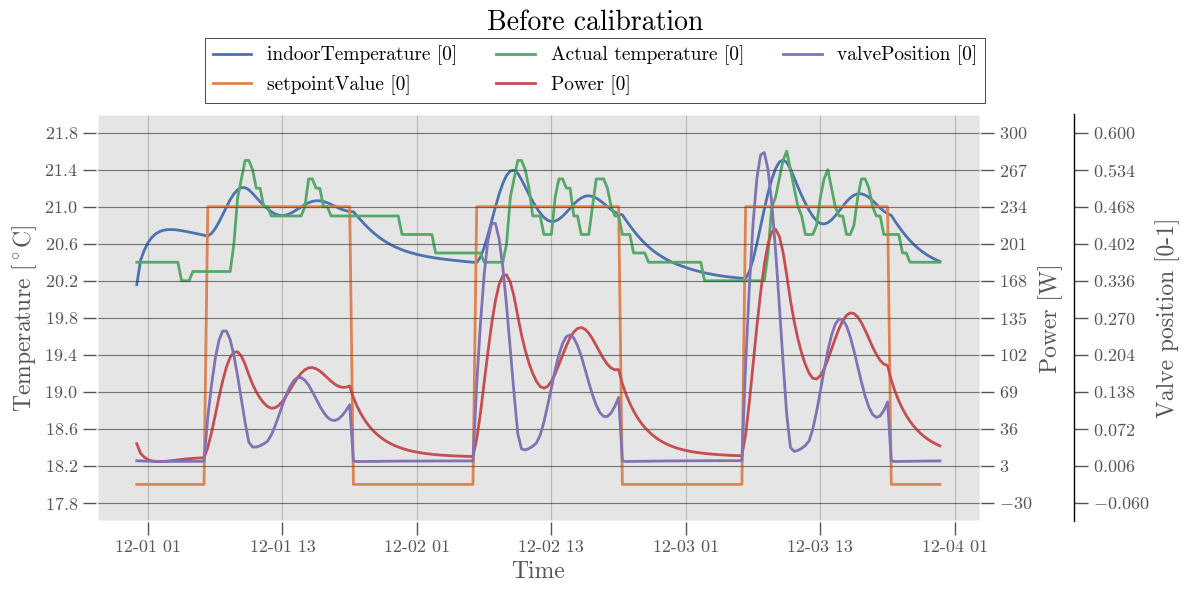

In [ ]:
fig, axes = tb.plot.plot_component(
    simulator,
    components_1axis=[
        ("office", "indoorTemperature", "output"),
        (heating_controller.id, "setpointValue", "input"),
        (model.components["office_temperature_sensor"].time_series_input.values, "Actual temperature"),
    ],
    components_2axis=[
        ("office_space_heater", "Power", "output"),
    ],
    components_3axis=[
        ("office_space_heater_valve", "valvePosition", "output"),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Power [W]",
    ylabel_3axis="Valve position [0-1]",
    title="Before calibration",
    show=True,
    nticks=11
)


### 2.7 Run Parameter Estimation

Calibrate the model using the SLSQP optimizer with automatic differentiation. On a typical laptop CPU, this takes around 5 minutes.

In [ ]:
estimator = tb.Estimator(simulator)
options = {"maxiter": 300,
"ftol": 1e-15}

# import torch
# torch.autograd.set_detect_anomaly(True)

result = estimator.estimate(
    start_time,
    end_time,
    step_size,
    parameters,
    measurements,
    n_warmup=72,
    method=("scipy", "SLSQP", "ad"),
    options=options,
)
result

In [ ]:
for x, id, attr in zip(result["result_x"], result["component_id"], result["component_attr"]):
    print(f"{id}.{attr} = {x}")

office.thermal.C_air = 87205.6673695263
office.thermal.C_wall = 397303.2272674095
office.thermal.C_boundary = 10000.000000000506
office.thermal.R_out = 0.49999999999997863
office.thermal.R_in = 0.49999999999999084
office.thermal.R_boundary = 0.016623274611373973
office.thermal.f_wall = 0.9999999999999928
office.thermal.f_air = 0.3128605609690031
office.thermal.Q_occ_gain = 100.0
office_space_heater.thermalMassHeatCapacity = 14494.73104482518
office_space_heater.UA = 6.172260131750516
office_temperature_heating_controller.kp = 0.00020416274685122981
office_co2_controller.kp = 0.00010000000000000009
office_temperature_heating_controller.Ti = 1.0000000000000278
office_co2_controller.Ti = 30.000000000000004
office_temperature_heating_controller.Td = 9.360600753852401e-18
office_co2_controller.Td = 0.0
office_space_heater_valve.waterFlowRateMax = 0.0002249325401785056
office_space_heater_valve.valveAuthority = 0.9999999999999916
office_supply_damper.a = 1.0
office_exhaust_damper.a = 1.0
off

### 2.8 Plot Calibrated Results

Run the simulation with calibrated parameters and compare against measurements.

In [ ]:
model.set_save_simulation_result(flag=True)
simulator.simulate(
    step_size=step_size,
    start_time=start_time,
    end_time=end_time
)
print("Calibration complete.")

100%|██████████| 216/216 [00:01<00:00, 183.88it/s]

Calibration complete.


216
torch.Size([216, 1])
torch.Size([216, 1])


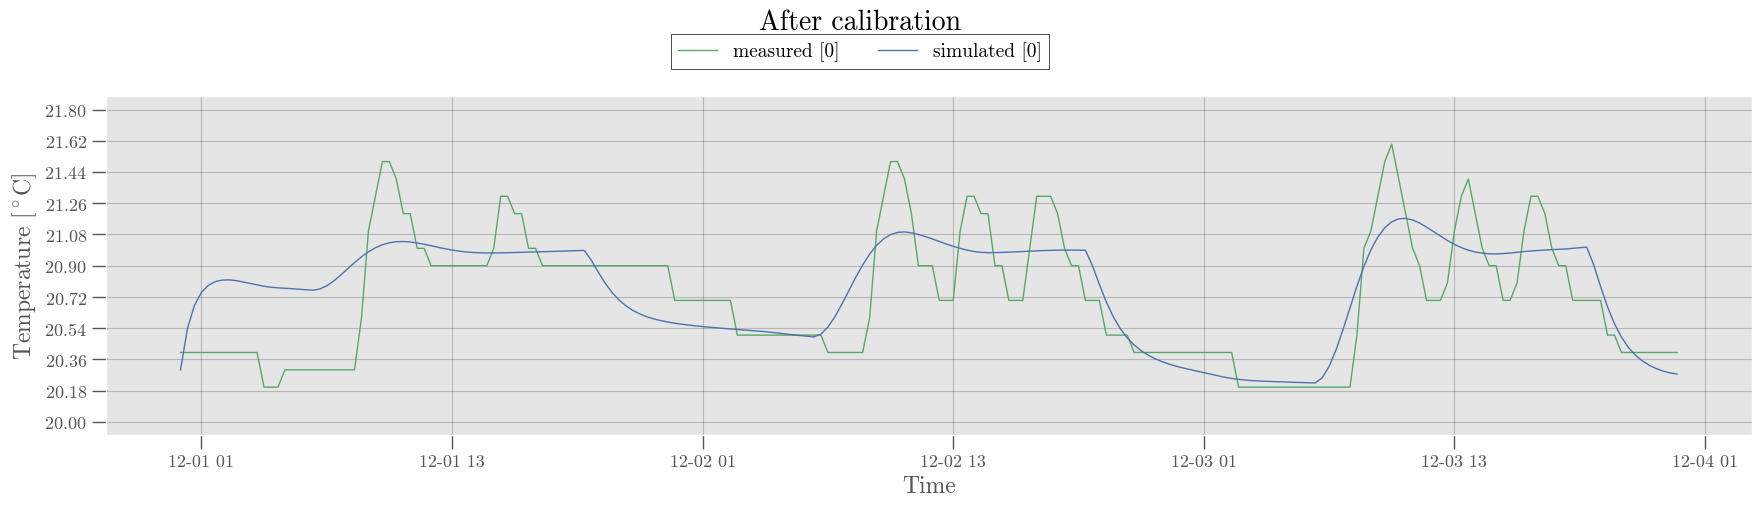

In [ ]:
print(len(simulator.date_time_steps[0]))
print(model.components["office_temperature_sensor"].time_series_input.values[:,:,0].shape)
print(model.components["office_temperature_sensor"].output["measuredValue"].history()[:,:,0].shape)
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [tb.plot.Entry(model.components["office_temperature_sensor"].time_series_input.values, label="measured", color=tb.plot.Colors.green, linewidth=1),
    tb.plot.Entry(model.components["office_temperature_sensor"].output["measuredValue"].history(), label="simulated", color=tb.plot.Colors.blue, linewidth=1)],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    title="After calibration",
    show=False,
    nticks=11
)
import matplotlib.pyplot as plt
fig.set_size_inches(18.5, 5)
plt.show()

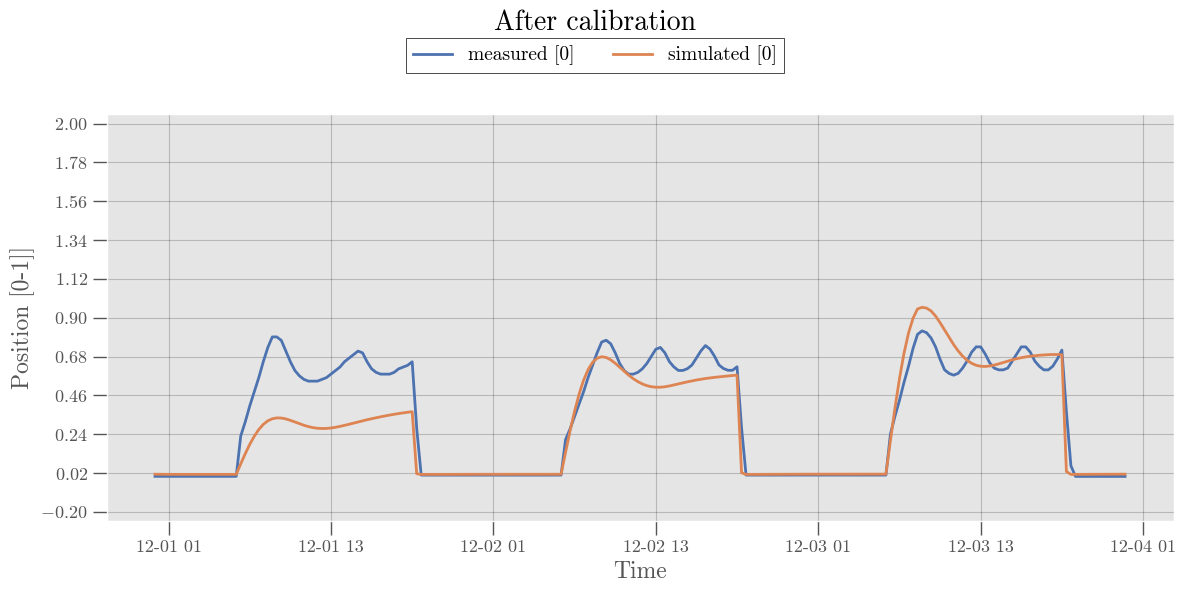

In [ ]:
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [tb.plot.Entry(model.components["office_valve_position_sensor"].time_series_input.values, label="measured"),
    tb.plot.Entry(model.components["office_valve_position_sensor"].output["measuredValue"].history(), label="simulated")],
    ylabel_1axis=r"Position [0-1]]",
    title="After calibration",
    show=True,
    nticks=11
)

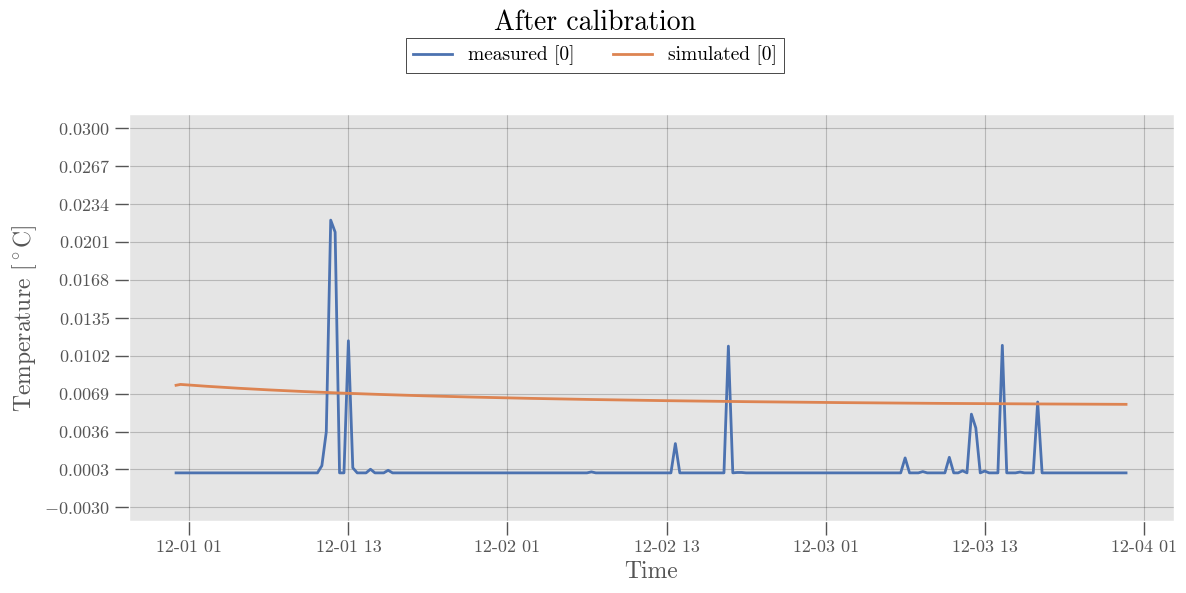

In [ ]:
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [tb.plot.Entry(model.components["office_damper_position_sensor"].time_series_input.values, label="measured"),
    tb.plot.Entry(model.components["office_damper_position_sensor"].output["measuredValue"].history(), label="simulated")],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    title="After calibration",
    show=True,
    nticks=11
)

### 2.9 Compare Valve Position: Measured vs. Simulated

A closer look at how well the calibrated model reproduces the measured valve position.

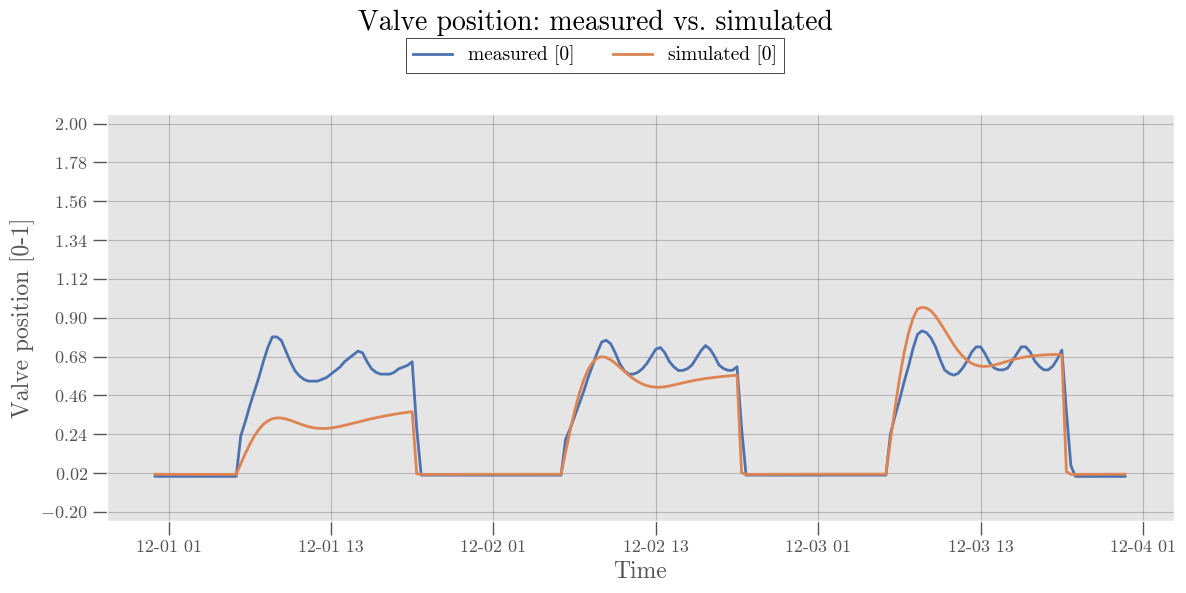

In [ ]:
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [tb.plot.Entry(model.components["office_valve_position_sensor"].time_series_input.values, label="measured"),
    tb.plot.Entry(model.components["office_valve_position_sensor"].output["measuredValue"].history(), label="simulated")],
    ylabel_1axis="Valve position [0-1]",
    title="Valve position: measured vs. simulated",
    show=True,
    nticks=11
)


---
# Part 3: Calibrated Model → Optimized Control (Optimizer)

Now that the model is calibrated, we use the Optimizer to find an optimal valve position schedule. The optimization minimizes the space heater power consumption while maintaining indoor temperature within comfort bounds defined by heating and cooling setpoints.

The decision variable is the valve position (0–1) that controls water flow through the space heater. The valve component converts this position into a water flow rate using the calibrated valve authority. The optimizer uses the calibrated model to predict how changes in valve position affect indoor temperature and energy use.

### 3.1 Create Optimizable Valve Position Schedule

For optimization, we replace the PID controller's output signal to the valve with a schedule that the optimizer can modify directly. We also set up heating/cooling setpoint schedules for the comfort constraints.

In [ ]:
import pandas as pd
df_valve = pd.DataFrame(model.components["office_valve_position_sensor"].output["measuredValue"].history()[:,0,0], index=simulator.date_time_steps[0])
valve_position_schedule = tb.SensorSystem(
    df=df_valve,
    id="ValvePositionSchedule"
)

valve_position_schedule = tb.ScheduleSystem(
    weekDayRulesetDict={
        "ruleset_default_value": 0,
        "ruleset_start_minute": [0, 0],
        "ruleset_end_minute": [0, 0],
        "ruleset_start_hour": [8, 19],
        "ruleset_end_hour": [16, 20],
        "ruleset_value": [0.5, 0.5],
    },
    id="valve_position_schedule"
)

# Load real Elspot prices from Dec 11-13, 2024 and remap dates to Dec 1-3, 2023
# (measurement data only covers 2023, so the simulation dates must stay in 2023)
elspot_raw = pd.read_csv(utils.get_path(["Elspotprices2023-2025.csv"]), sep=";", decimal=",")
elspot_raw["HourDK"] = pd.to_datetime(elspot_raw["HourDK"], dayfirst=True)

src_start = pd.Timestamp("2024-12-11")
src_end = pd.Timestamp("2024-12-14")  # exclusive
mask = (elspot_raw["HourDK"] >= src_start) & (elspot_raw["HourDK"] < src_end)
elspot_subset = elspot_raw.loc[mask, ["HourDK", "SpotPriceDKK"]].copy()

# Shift dates: Dec 11-13 2024 -> Dec 1-3 2023 (within measurement data range)
date_offset = pd.DateOffset(years=1, days=10)  # 2024-12-11 minus 1 year and 10 days = 2023-12-01
elspot_subset["HourDK"] = elspot_subset["HourDK"] - date_offset
elspot_subset.columns = ["time", "value"]
elspot_subset["value"] = elspot_subset["value"] / 1000  # DKK/MWh -> DKK/kWh
elspot_subset = elspot_subset.sort_values("time").reset_index(drop=True)

elspot_clean_path = utils.get_path(["estimator_example", "electricity_price.csv"])
elspot_subset.to_csv(elspot_clean_path, index=False)
print(f"Using real Elspot prices from Dec 11-13, 2024 (remapped to Dec 1-3, 2023)")
print(f"Price range: {elspot_subset['value'].min():.4f} - {elspot_subset['value'].max():.4f} DKK/kWh")
print(elspot_subset.head())

price_schedule = tb.ScheduleSystem(
    filename=elspot_clean_path,
    datecolumn=0,
    valuecolumn=1,
    id="price_schedule"
)

# Multiplies Power (W) by price (DKK/kWh), with scale_factor converting W·s to kWh
costs_sensor = tb.ScalarProductSystem(
    scale_factor=step_size/3600/1000,  # W -> kWh per timestep
    id="costs_sensor"
)

heating_setpoint = model.components["office_temperature_heating_setpoint"]

cooling_setpoint = tb.ScheduleSystem(
    weekDayRulesetDict={
        "ruleset_default_value": 0,
        "ruleset_start_minute": [0, 0, 0],
        "ruleset_end_minute": [0, 0, 0],
        "ruleset_start_hour": [0, 8, 17],
        "ruleset_end_hour": [8, 17, 24],
        "ruleset_value": [30, 25, 30],
    },
    id="CoolingSetpoint"
)

Using real Elspot prices from Dec 11-13, 2024 (remapped to Dec 1-3, 2023)
Price range: 0.7918 - 6.9824 DKK/kWh
                 time    value
0 2023-12-01 00:00:00  0.86469
1 2023-12-01 01:00:00  0.80711
2 2023-12-01 02:00:00  0.80033
3 2023-12-01 03:00:00  0.79182
4 2023-12-01 04:00:00  0.81062


### 3.2 Rewire the Model for Optimization

Remove the PID heating controller's output signal to the valve and replace it with the optimizable valve position schedule. The valve component remains in the model and converts the optimized position into a water flow rate using its calibrated parameters (valve authority, max flow rate).

In [ ]:
model.remove_connection(heating_controller, space_heater_valve, "inputSignal", "valvePosition")
model.add_connection(valve_position_schedule, space_heater_valve, "scheduleValue", "valvePosition")
model.add_connection(space_heater, costs_sensor, "Power", "input_1")
model.add_connection(price_schedule, costs_sensor, "scheduleValue", "input_2")
model.load()

print("Model rewired for optimization.")
print(model)

Model rewired for optimization.
+-------------------------------------------------------------------------------------------------------------------------------+
|                                          Model overview    id: full_workflow_example                                          |
+---------------------------------------------+---------------------------------------------------------------------------------+
|  Number of components in simulation model:  |                                        21                                       |
+---------------------------------------------+---------------------------------------------------------------------------------+
| Number of connections in simulation model:  |                                        48                                       |
+---------------------------------------------+---------------------------------------------------------------------------------+
|              Model directory:               | C:\Users\j

### 3.3 Set Up Optimization Parameters

Define the optimization time window. We use a single period for the optimization run.

In [ ]:
opt_step_size = step_size
opt_start_time = [
    datetime.datetime(year=2023, month=12, day=1, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
]
opt_end_time = [
    datetime.datetime(year=2023, month=12, day=4, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
]

print(f"Optimization period: {opt_start_time[0]} to {opt_end_time[0]} (3 days)")
print(f"Step size: {opt_step_size} seconds ({opt_step_size/60} minutes)")
print(f"Using real Elspot prices from Dec 11-13, 2024")

Optimization period: 2023-12-01 00:00:00+01:00 to 2023-12-04 00:00:00+01:00 (3 days)
Step size: 1200 seconds (20.0 minutes)
Using real Elspot prices from Dec 11-13, 2024


### 3.4 Run Initial Simulation (Before Optimization)

Simulate with the default valve position schedule to see the baseline performance of the calibrated model.

100%|██████████| 216/216 [00:01<00:00, 166.24it/s]


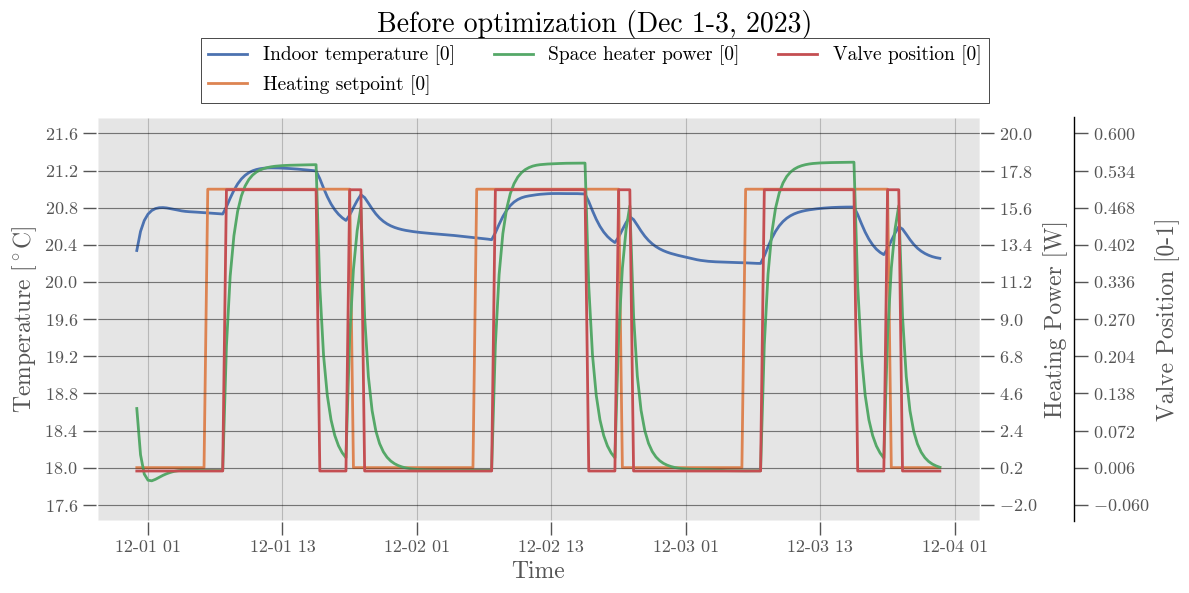

In [ ]:
simulator_opt = tb.Simulator(model)
simulator_opt.simulate(
    step_size=opt_step_size,
    start_time=opt_start_time,
    end_time=opt_end_time
)

fig, axes = tb.plot.plot(
    simulator_opt.date_time_steps,
    [tb.plot.Entry(space.output["indoorTemperature"].history(), label="Indoor temperature"),
    tb.plot.Entry(heating_setpoint.output["scheduleValue"].history(), label="Heating setpoint"),
    tb.plot.Entry(space_heater.output["Power"].history(), label="Space heater power", axis=2),
    tb.plot.Entry(space_heater_valve.output["valvePosition"].history(), label="Valve position", axis=3),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Heating Power [W]",
    ylabel_3axis="Valve Position [0-1]",
    title="Before optimization (Dec 1-3, 2023)",
    show=True,
)

### 3.5 Run Optimization

Optimize the valve position schedule to minimize heater power consumption subject to indoor temperature comfort constraints. The valve position ranges from 0 (fully closed) to 1 (fully open). On a typical laptop CPU, this takes around 2 minutes.

In [ ]:
variables = [
    (valve_position_schedule, "scheduleValue", 0, 1)
]

objectives = [
    (costs_sensor, "output", "min")
]

ineq_cons = [
    (space, "indoorTemperature", "upper", cooling_setpoint),
    (space, "indoorTemperature", "lower", heating_setpoint),
]

optimizer = tb.Optimizer(simulator_opt)

opt_options = {
    "maxiter": 300,
    "tol": 1e-15,
    "disp": True
}

optimizer.optimize(
    start_time=opt_start_time,
    end_time=opt_end_time,
    step_size=opt_step_size,
    variables=variables,
    objectives=objectives,
    eq_cons=None,
    ineq_cons=ineq_cons,
    method="scipy",
    options=opt_options
)

### 3.6 Plot Optimization Results

Visualize the optimized valve position schedule and its effect on indoor temperature and power consumption. The optimized valve position should maintain comfort (temperature between heating and cooling setpoints) while minimizing energy use.

Total cost: 3.81 DKK
Peak cost/step: 0.0789 DKK
Peak power: 68.5 W


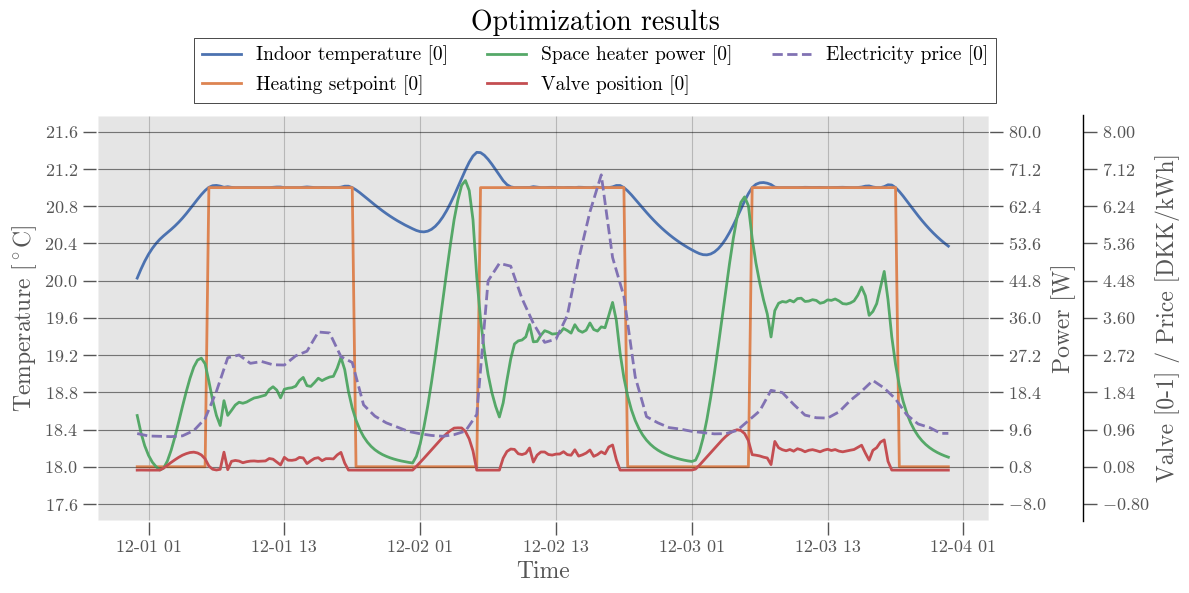

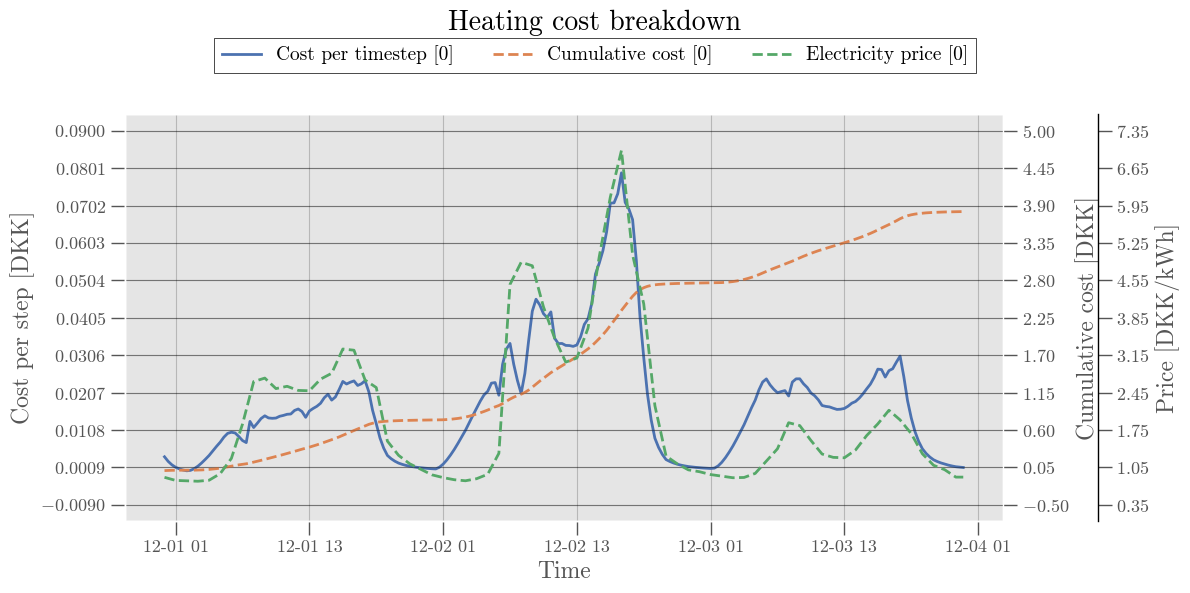

In [ ]:
model.add_component(cooling_setpoint)
model.add_component(heating_setpoint)

cost_history = costs_sensor.output["output"].history()[:,0,0]
power_history = space_heater.output["Power"].history()[:,0,0]
price_history = price_schedule.output["scheduleValue"].history()[:,0,0]
cumulative_cost = cost_history.cumsum(dim=0)
print(f"Total cost: {cost_history.sum():.2f} DKK")
print(f"Peak cost/step: {cost_history.max():.4f} DKK")
print(f"Peak power: {power_history.max():.1f} W")

fig, axes = tb.plot.plot(
    simulator_opt.date_time_steps,
    [tb.plot.Entry(space.output["indoorTemperature"].history(), label="Indoor temperature"),
    tb.plot.Entry(heating_setpoint.output["scheduleValue"].history(), label="Heating setpoint"),
    tb.plot.Entry(space_heater.output["Power"].history(), label="Space heater power", axis=2),
    tb.plot.Entry(space_heater_valve.output["valvePosition"].history(), label="Valve position", axis=3),
    tb.plot.Entry(price_schedule.output["scheduleValue"].history(), label="Electricity price", fmt="--", axis=3),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Power [W]",
    ylabel_3axis="Valve [0-1] / Price [DKK/kWh]",
    title="Optimization results",
    show=True,
)

fig, axes = tb.plot.plot(
    simulator_opt.date_time_steps,
    [tb.plot.Entry(costs_sensor.output["output"].history(), label="Cost per timestep"),
    tb.plot.Entry(cumulative_cost.unsqueeze(-1).unsqueeze(-1), label="Cumulative cost", fmt="--", axis=2),
    tb.plot.Entry(price_schedule.output["scheduleValue"].history(), label="Electricity price", fmt="--", axis=3),
    ],
    ylabel_1axis="Cost per step [DKK]",
    ylabel_2axis="Cumulative cost [DKK]",
    ylabel_3axis="Price [DKK/kWh]",
    title="Heating cost breakdown",
    show=True,
)

---
## Summary

This notebook demonstrated the complete Twin4Build workflow:

1. **Translation**: A semantic model (Excel file with SAREF ontologies) was automatically translated into an executable simulation model
2. **Estimation**: The simulation model parameters were calibrated against real sensor data using gradient-based optimization with automatic differentiation
3. **Optimization**: The calibrated model was used to find an energy-optimal valve position schedule while satisfying indoor thermal comfort constraints

This end-to-end pipeline shows how Twin4Build enables:
- **Interoperability** through ontology-based semantic modeling
- **Accuracy** through data-driven parameter calibration
- **Efficiency** through model-based optimal control